In [2]:
# Import Librarues

import pandas as pd
import numpy as np
#import plotlib as plt


In [19]:
#Load the File

df = pd.read_csv('/content/Mumbai House Prices.csv')

In [20]:
df

,bhk,type,locality,area,price,price_unit,region,status,age
0,3,Apartment,Lak And Hanware The Residency Tower,685,2.50,Cr,Andheri West,Ready to move,New
1,2,Apartment,Radheya Sai Enclave Building No 2,640,52.51,L,Naigaon East,Under Construction,New
2,2,Apartment,Romell Serene,610,1.73,Cr,Borivali West,Under Construction,New
3,2,Apartment,Soundlines Codename Urban Rainforest,876,59.98,L,Panvel,Under Construction,New
4,2,Apartment,Origin Oriana,659,94.11,L,Mira Road East,Under Construction,New
...,...,...,...,...,...,...,...,...,...
76033,3,Apartment,Parinee Liva Roca,1527,7.00,Cr,Juhu,Ready to move,Unknown
76034,5,Apartment,Parinee Liva Roca,3049,12.00,Cr,Juhu,Ready to move,Unknown
76035,4,Apartment,Lodha Seaview,3313,10.00,Cr,Napeansea Road,Ready to move,Unknown
76036,2,Apartment,Hubtown Serene,1305,4.25,Cr,Bandra East,Ready to move,Unknown


In [21]:
df.shape

(76038, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76038 entries, 0 to 76037
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   bhk         76038 non-null  int64  
 1   type        76038 non-null  object 
 2   locality    76038 non-null  object 
 3   area        76038 non-null  int64  
 4   price       76038 non-null  float64
 5   price_unit  76038 non-null  object 
 6   region      76038 non-null  object 
 7   status      76038 non-null  object 
 8   age         76038 non-null  object 
dtypes: float64(1), int64(2), object(6)
memory usage: 5.2+ MB


In [22]:
df.describe()

,bhk,area,price
count,76038.000000,76038.000000,76038.00000
mean,2.015111,1024.536850,29.38227
std,0.922754,670.276165,32.90345
min,1.000000,127.000000,1.00000
25%,1.000000,640.000000,1.75000
50%,2.000000,872.000000,5.50000
75%,3.000000,1179.000000,59.00000
max,10.000000,16000.000000,99.99000


In [25]:
#Check Duplicates
df.duplicated().sum()

np.int64(20312)

In [27]:
df_len = len(df)
df_len

76038

In [28]:
df = df.drop_duplicates()
print(df_len, '->', len(df), '| dropped:', df_len - len(df))

76038 -> 55726 | dropped: 20312


In [30]:
print(df.duplicated().sum())

0


In [31]:
#Create price_lakhs

df['price_lakhs'] = np.where(df['price_unit'] == 'Cr', df['price'] * 100, df['price'])
print(df[['price', 'price_unit', 'price_lakhs']].head())

   price price_unit  price_lakhs
0   2.50         Cr       250.00
1  52.51          L        52.51
2   1.73         Cr       173.00
3  59.98          L        59.98
4  94.11          L        94.11


/tmp/ipykernel_1000/1901244916.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['price_lakhs'] = np.where(df['price_unit'] == 'Cr', df['price'] * 100, df['price'])


In [29]:
print(df.shape)   # expect (76038, 9)

(55726, 9)


In [32]:
#

In [15]:
#Step 2. Put every price in lakhs
df['price_display'] = df['price'].round(2).astype(str) + ' ' + df['price_unit']
print(df[['price', 'price_unit', 'price_display']].head())

   price price_unit price_display
0   2.50         Cr        2.5 Cr
1  52.51          L       52.51 L
2   1.73         Cr       1.73 Cr
3  59.98          L       59.98 L
4  94.11          L       94.11 L


In [36]:
#Drop rows where age is "Unknown"
for_age_len = len(df['age'])
for_age_len


55726

In [37]:
df = df[df['age'] != 'Unknown']
print(for_age_len, '->', len(df), '| dropped:', for_age_len - len(df))

55726 -> 47191 | dropped: 8535


In [46]:
df['age'] == 'Unknown'

,age
0,False
1,False
2,False
3,False
4,False
...,...
76011,False
76012,False
76013,False
76025,False


In [47]:
# Keep area between 250 and 10,000 (inclusive)
area_len_before = len(df)
area_len_before


47191

In [48]:
df = df[df['area'].between(250, 10000)]
print(area_len_before, '->', len(df), '| dropped:', area_len_before - len(df))

47191 -> 47075 | dropped: 116


In [49]:
# Keep price_lakhs between 10 and 2,000 (inclusive)
Price_lac_len = len(df)
Price_lac_len


47075

In [50]:
df = df[df['price_lakhs'].between(10, 2000)]
print(Price_lac_len, '->', len(df), '| dropped:', Price_lac_len - len(df))

47075 -> 46976 | dropped: 99


In [52]:
df = df.reset_index(drop=True)

df

,bhk,type,locality,area,price,price_unit,region,status,age,price_lakhs
0,3,Apartment,Lak And Hanware The Residency Tower,685,2.50,Cr,Andheri West,Ready to move,New,250.00
1,2,Apartment,Radheya Sai Enclave Building No 2,640,52.51,L,Naigaon East,Under Construction,New,52.51
2,2,Apartment,Romell Serene,610,1.73,Cr,Borivali West,Under Construction,New,173.00
3,2,Apartment,Soundlines Codename Urban Rainforest,876,59.98,L,Panvel,Under Construction,New,59.98
4,2,Apartment,Origin Oriana,659,94.11,L,Mira Road East,Under Construction,New,94.11
...,...,...,...,...,...,...,...,...,...,...
46971,2,Apartment,Arkade Earth Fern,707,1.98,Cr,Kanjurmarg,Under Construction,New,198.00
46972,2,Apartment,Arkade Earth Fern,677,1.88,Cr,Kanjurmarg,Under Construction,New,188.00
46973,2,Apartment,Arkade Earth Fern,681,1.89,Cr,Kanjurmarg,Under Construction,New,189.00
46974,2,Apartment,NARANG REALTY And WADHWA GROUP Courtyard,762,1.77,Cr,Thane West,Ready to move,New,177.00


In [55]:
#A2
print(df['price_lakhs'].median())

# A3
cnt_mxm = df.groupby('region')['price_lakhs'].agg(['count', 'median'])
cnt_mxm = cnt_mxm[cnt_mxm['count'] >= 100]
print(g['median'].idxmax(), cnt_mxm['median'].max())

97.0
Worli 750.0


Step 4. Explore


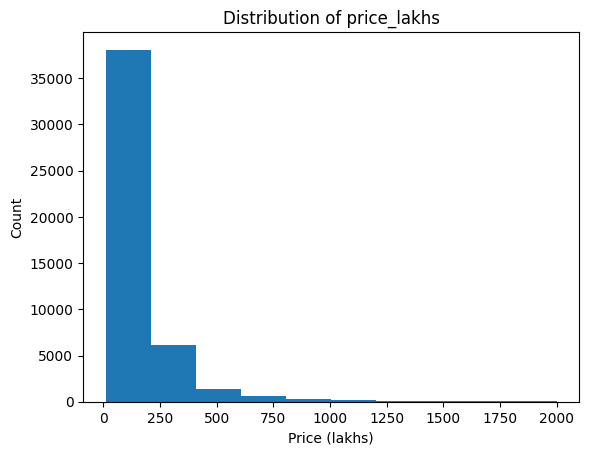

In [58]:
import matplotlib.pyplot as plt

# 1. Histogram
df['price_lakhs'].plot.hist(bins=10)
plt.title('Distribution of price_lakhs'); plt.xlabel('Price (lakhs)'); plt.ylabel('Count')
plt.show()

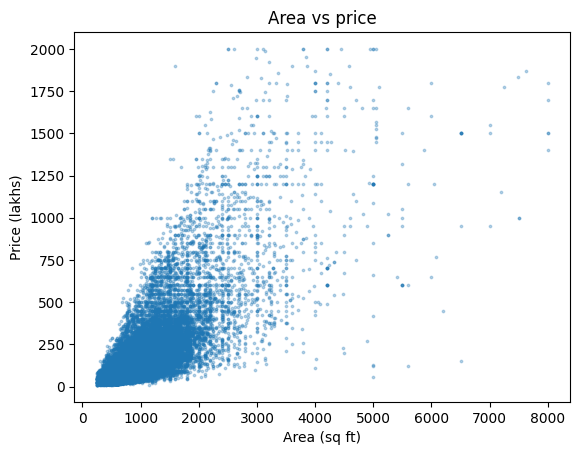

In [59]:
# 2. Scatter
plt.scatter(df['area'], df['price_lakhs'], s=3, alpha=0.3)
plt.title('Area vs price'); plt.xlabel('Area (sq ft)'); plt.ylabel('Price (lakhs)')
plt.show()


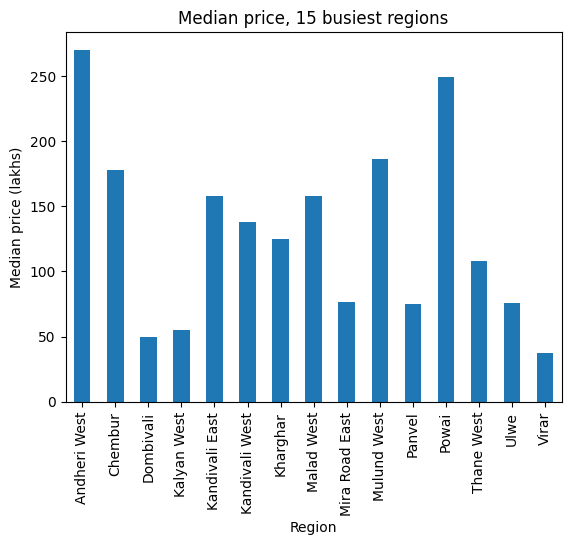

In [60]:
# 3. Bar: median price of top 15 regions by listing count
top15_regions = df['region'].value_counts().head(15).index
df[df['region'].isin(top15_regions)].groupby('region')['price_lakhs'].median().plot.bar()
plt.title('Median price, 15 busiest regions'); plt.xlabel('Region'); plt.ylabel('Median price (lakhs)')
plt.show()


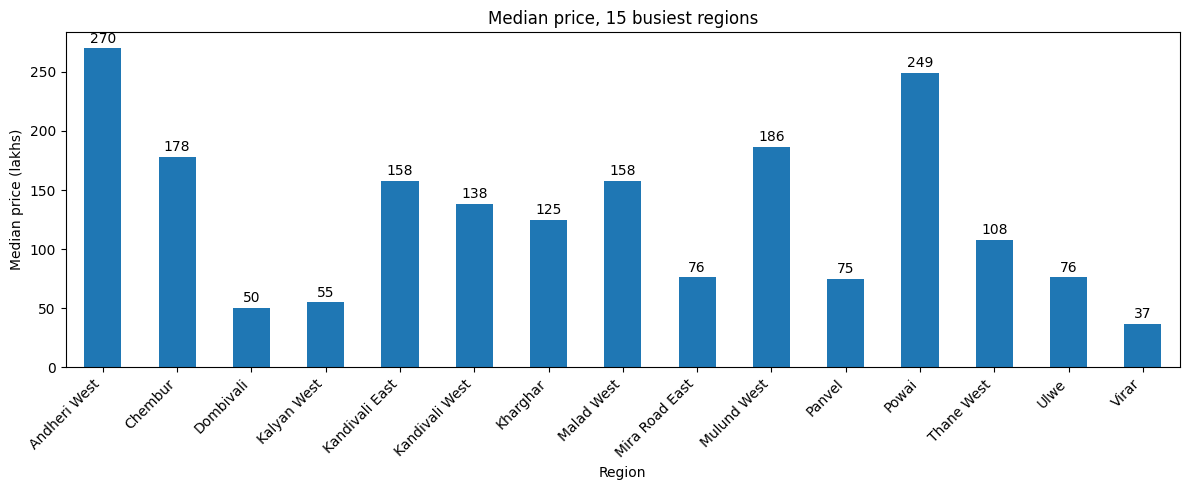

In [61]:
top15_regions = df['region'].value_counts().head(15).index
med = df[df['region'].isin(top15_regions)].groupby('region')['price_lakhs'].median()

ax = med.plot.bar(figsize=(12, 5))
ax.bar_label(ax.containers[0], fmt='%.0f', padding=2)
ax.set_title('Median price, 15 busiest regions')
ax.set_xlabel('Region')
ax.set_ylabel('Median price (lakhs)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

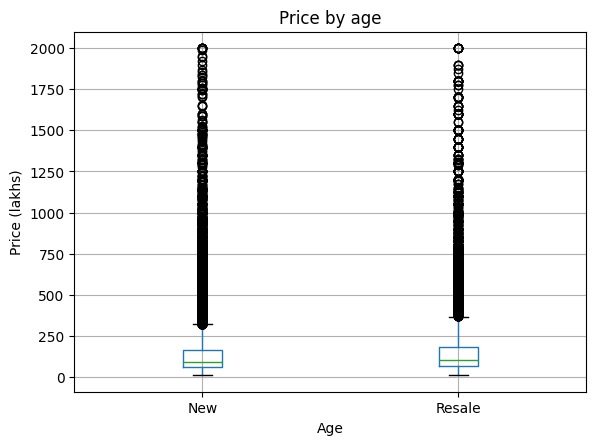

In [62]:
# 4. Box plot: New vs Resale
df.boxplot(column='price_lakhs', by='age')
plt.title('Price by age'); plt.suptitle(''); plt.xlabel('Age'); plt.ylabel('Price (lakhs)')
plt.show()

In [63]:
# A4
print(df['area'].corr(df['price_lakhs']))

# A6
print(df.groupby('age')['price_lakhs'].median())

0.7354053544857129
age
New        93.45
Resale    106.00
Name: price_lakhs, dtype: float64


Step 5. Log-transform the target

skew price_lakhs: 4.242601786193739
skew log_price:   0.4152202085645013


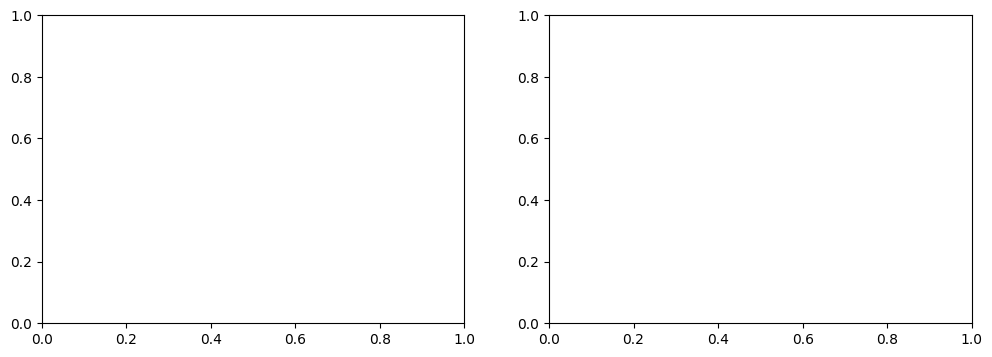

In [65]:
df['log_price'] = np.log(df['price_lakhs'])

print('skew price_lakhs:', df['price_lakhs'].skew())
print('skew log_price:  ', df['log_price'].skew())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

In [66]:
df['price_lakhs'].plot.hist(bins=50, ax=axes[0])
axes[0].set_title('Distribution of price_lakhs')
axes[0].set_xlabel('Price (lakhs)')
axes[0].set_ylabel('Count')

Text(4.444444444444466, 0.5, 'Count')

In [67]:
df['log_price'].plot.hist(bins=50, ax=axes[1])
axes[1].set_title('Distribution of log_price')
axes[1].set_xlabel('log(Price in lakhs)')
axes[1].set_ylabel('Count')

Text(511.7171717171717, 0.5, 'Count')

In [68]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [71]:
# A5
print(df['price_lakhs'].skew())                    # positive = right-skewed
print(df['price_lakhs'].mean(),
      df['price_lakhs'].median())   # mean > median

4.242601786193739
152.62814181709808 97.0


Step 6. Features, encoding and the split

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

X = df[["bhk", "area", "type", "locality", "region", "status", "age"]]
y = np.log(df["price_lakhs"])


In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [75]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), ["bhk", "area"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"),
     ["type", "locality", "region", "status", "age"]),
])

print(X_train.shape, X_test.shape)

(37580, 7) (9396, 7)


In [76]:


print(X_train.info, X_test.info)

<bound method DataFrame.info of        bhk  area       type  \
7900     2  1250  Apartment   
38383    1   650  Apartment   
38127    1   695  Apartment   
22370    2   797  Apartment   
22170    3  1370  Apartment   
...    ...   ...        ...   
11284    1   576  Apartment   
44732    2   995  Apartment   
38158    4  1090  Apartment   
860      1   658  Apartment   
15795    2   624  Apartment   

                                                locality           region  \
7900                             Hiranandani Castle Rock            Powai   
38383                   Ramji Hari Minat Naagraj Classic             Ulwe   
38127                                  Shagun White Nest             Ulwe   
22370  Rajsanket Rajinfinia Phase II Wing A Wing B Wi...       Malad West   
22170                                 Universal Garden 2  Jogeshwari West   
...                                                  ...              ...   
11284                                     JP North Aviva

In [77]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error



In [80]:
LR = Pipeline([("prep", preprocessor), ("model", LinearRegression())])
LR.fit(X_train, y_train)



Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['bhk', 'area']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['type', 'locality', 'region',
                                                   'status', 'age'])])),
                ('model', LinearRegression())])

In [81]:
pred_train = LR.predict(X_train)
pred = LR.predict(X_test)

print("train R2:", r2_score(y_train, pred_train))
print("test R2: ", r2_score(y_test, pred))
print("test RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

train R2: 0.9771332431863284
test R2:  0.9327722038582603
test RMSE: 0.20905083140903544


In [82]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV


In [83]:
hypertune_grid = {"model__alpha": [0.001, 0.01, 0.1, 1, 5]}

In [86]:
# Ridge
ridge_pipe = Pipeline([("prep", preprocessor), ("model", Ridge())])
ridge_gs = GridSearchCV(ridge_pipe, hypertune_grid, cv=5)
ridge_gs.fit(X_train, y_train)
ridge_best = ridge_gs.best_estimator_

print("Ridge best alpha:", ridge_gs.best_params_["model__alpha"])
print("Ridge train R2:", r2_score(y_train, ridge_best.predict(X_train)))
print("Ridge test R2: ", r2_score(y_test, ridge_best.predict(X_test)))

Ridge best alpha: 0.1
Ridge train R2: 0.9765590237922723
Ridge test R2:  0.9495212183374545


In [87]:
# Lasso
lasso_pipe = Pipeline([("prep", preprocessor), ("model", Lasso(max_iter=10000))])
lasso_gs = GridSearchCV(lasso_pipe, hypertune_grid, cv=5)
lasso_gs.fit(X_train, y_train)
lasso_best = lasso_gs.best_estimator_

lasso_model = lasso_best.named_steps["model"]
print("Lasso best alpha:", lasso_gs.best_params_["model__alpha"])
print("Lasso train R2:", r2_score(y_train, lasso_best.predict(X_train)))
print("Lasso test R2: ", r2_score(y_test, lasso_best.predict(X_test)))
print("Lasso zero coefficients:", (lasso_model.coef_ == 0).sum())

Lasso best alpha: 0.001
Lasso train R2: 0.8642541236240237
Lasso test R2:  0.8677895318954394
Lasso zero coefficients: 7886


In [89]:
models = {"Linear": LR, "Ridge": ridge_best, "Lasso": lasso_best}

rows = []
for name, m in models.items():
    p_train = m.predict(X_train)
    p_test = m.predict(X_test)
    rows.append({
        "model": name,
        "train_R2": r2_score(y_train, p_train),
        "test_R2": r2_score(y_test, p_test),
        "test_RMSE": np.sqrt(mean_squared_error(y_test, p_test)),
    })

results = pd.DataFrame(rows).set_index("model")
print(results)

best = results["test_R2"].idxmax()
print("Best model on test R2:", best)

        train_R2   test_R2  test_RMSE
model                                
Linear  0.977133  0.932772   0.209051
Ridge   0.976559  0.949521   0.181147
Lasso   0.864254  0.867790   0.293164
Best model on test R2: Ridge


In [93]:
final = models[best]   # best from Step 9
prep = final.named_steps["prep"]
coef = final.named_steps["model"].coef_

names = prep.get_feature_names_out()
coef_df = pd.DataFrame({"feature": names, "coef": coef})
coef_df["abs_coef"] = coef_df["coef"].abs()

top10_coff = coef_df.sort_values("abs_coef", ascending=False).head(10)
print(top10_coff)

                                               feature      coef  abs_coef
5013              cat__locality_Reputed Builder Rashmi -2.220879  2.220879
5344  cat__locality_Reputed Builder Sunshine Apartment -2.154519  2.154519
4478            cat__locality_Reputed Builder Gardenia -2.142992  2.142992
4775         cat__locality_Reputed Builder Mansi Vihar -2.101216  2.101216
773                            cat__locality_Braj City -2.097865  2.097865
5889    cat__locality_Sachiv Surinder Sahni The Legacy -2.000255  2.000255
5286       cat__locality_Reputed Builder Silver Square -1.735745  1.735745
5449     cat__locality_Reputed Builder Venus Apartment -1.674429  1.674429
5006       cat__locality_Reputed Builder Rajani Gandha -1.654002  1.654002
6239       cat__locality_Shalibhadra Shalibhadra Amora -1.644804  1.644804


In [95]:
 #A11: original column of the largest coefficient
print("Top feature:", top10.iloc[0]["feature"])

# A12: overfitting gap
gap = r2_score(y_train, final.predict(X_train)) - r2_score(y_test, final.predict(X_test))
print("Gap:", gap)
print("Overfitting:", gap > 0.05)

Top feature: cat__locality_Reputed Builder Rashmi
Gap: 0.02703780545481782
Overfitting: False


In [96]:
# df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(20)

In [98]:
# df['price_lakhs'] = np.where(df['price_unit'] == 'Cr', df['price'] * 100, df['price'])
# df['price_lakhs']